In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
# See available dataset
print(sns.get_dataset_names())
# Seaborn returns a list of the dataset names it knows how to download.
# Those datasets were chosen because they're small, clean, and useful for teaching 
# common data analysis and machine learning concepts.
# If other dataset needed we have to load it using pandas

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


**Explore the dataset**

In [3]:
# I am choosing Titanic dataset here
df = sns.load_dataset('titanic')

In [ ]:
df.head()
# This is pure raw data but titanic dataset that i used in pandas notebook that was 
# clean and processed data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# We will move forward by answering important questions and visualizing with different 
# types of plotting. By this, we can also understand the significance of these plottings.

**Count Plot**

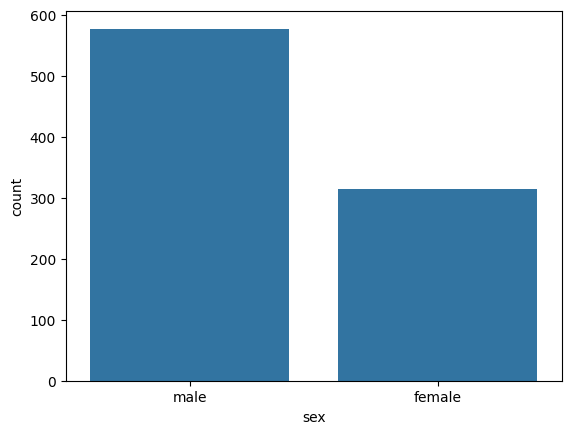

In [ ]:
# Univariate Analysis
# How many males vs females were onboard?
sns.countplot(data=df, x='sex')
plt.show()

<Axes: xlabel='pclass', ylabel='count'>

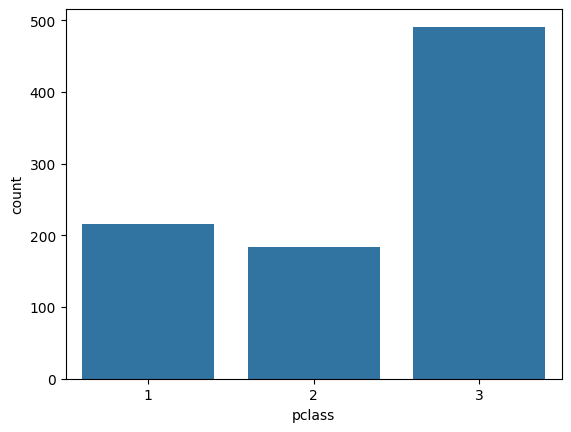

In [13]:
# Which class had the most passengers?
sns.countplot(data= df, x='pclass')

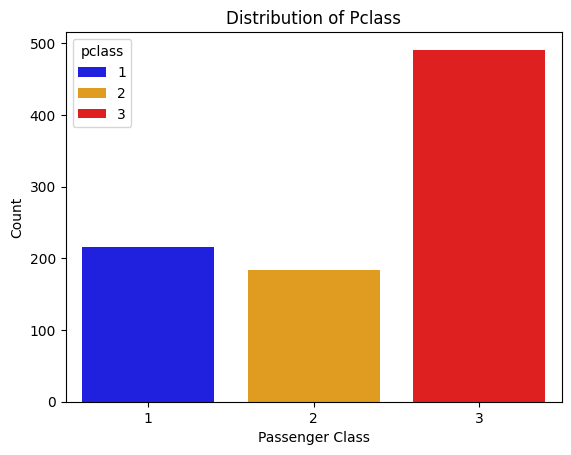

In [54]:
# Customizing color: 
sns.countplot(x='pclass', hue ='pclass', data = df, palette=["blue","orange","red"])
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.title("Distribution of Pclass")

plt.show()

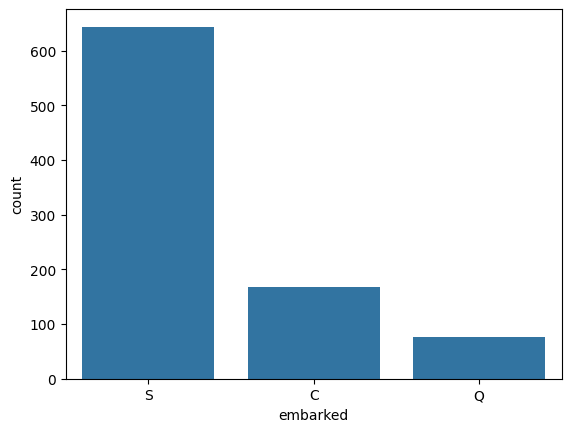

In [ ]:
# Which port had the most passengers?
sns.countplot(data=df, x='embark_town') # or x='embarked'
plt.show()

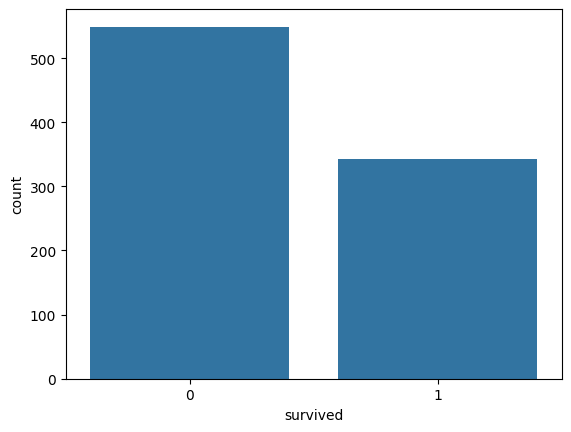

In [ ]:
# How many survived vs died?
sns.countplot(data=df, x='survived') # x= 'alive'
plt.show()

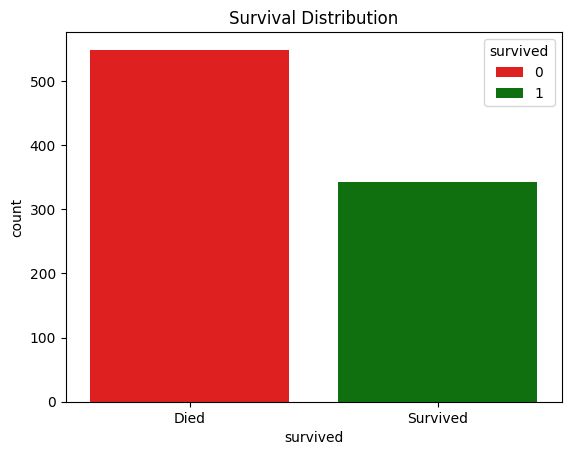

In [ ]:
# Customization
sns.countplot(x='survived',hue ='survived', data=df, palette=["red", "green"])
plt.xticks([0,1],['Died', 'Survived'])
plt.title("Survival Distribution")
plt.show()

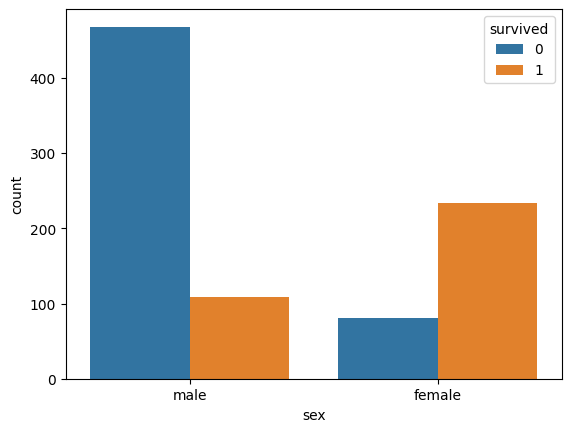

In [ ]:
# Bivariate Analysis
# countplot + hue
# Did women survive more often?
sns.countplot(data=df, x='sex', hue='survived')
plt.show()

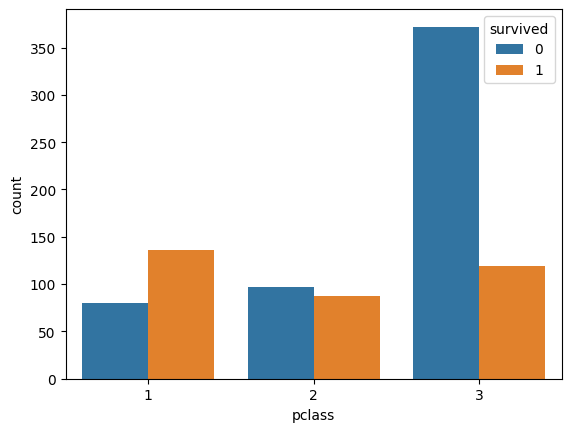

In [ ]:
# Which class passengers survived more ?
sns.countplot(data=df, x='pclass', hue='survived')
plt.show()

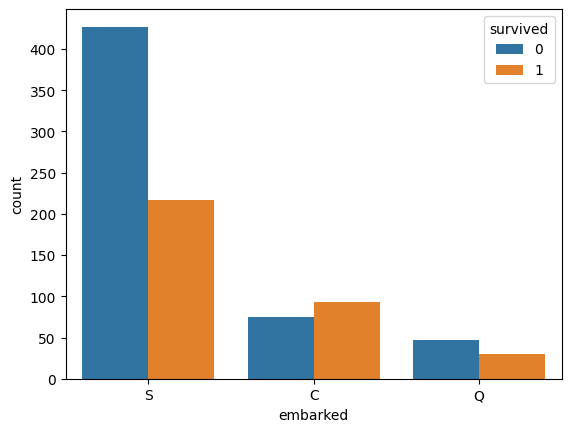

In [21]:
# Which embarkation town had the best survival rate?
sns.countplot(data=df, x='embarked', hue='survived')
plt.show()

**Histogram**

<Axes: xlabel='age', ylabel='Count'>

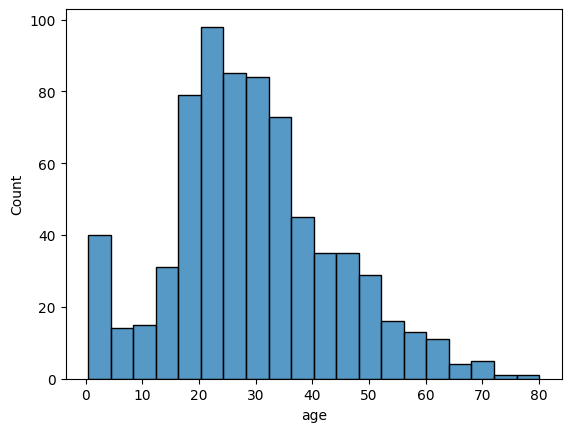

In [22]:
# What is the age distribution?
sns.histplot(data=df, x="age")

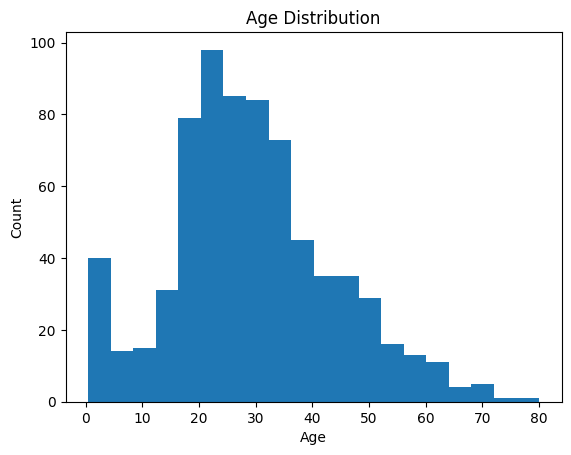

In [53]:
# Alternative: 
plt.hist(df["age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")

plt.show()

In [25]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

<Axes: xlabel='fare', ylabel='Count'>

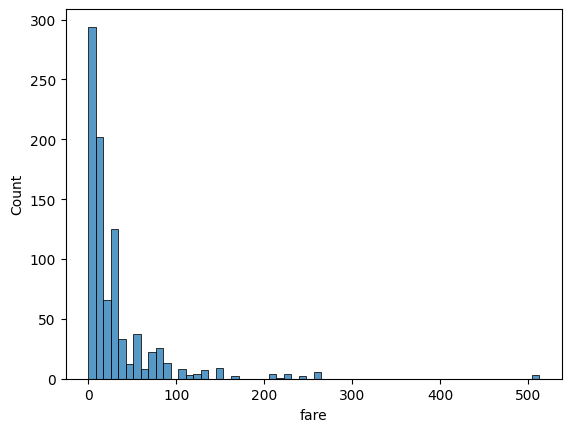

In [ ]:
# What is the fare distribution ?
sns.histplot(data=df, x='fare')
# Right skewed distribution

<Axes: xlabel='age', ylabel='Count'>

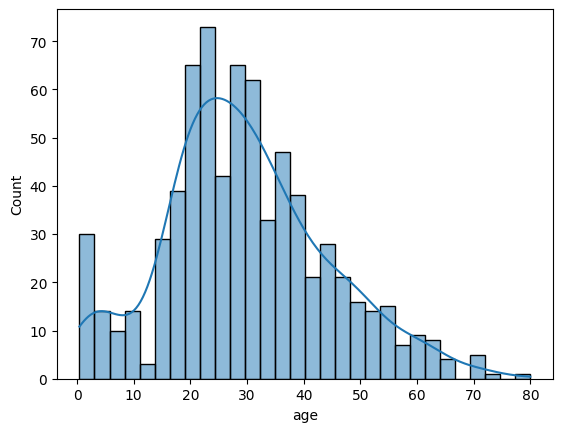

In [30]:
# Are most passengers young or old?
sns.histplot(data=df, x='age',bins=30, kde=True)

**Scatter Plot**

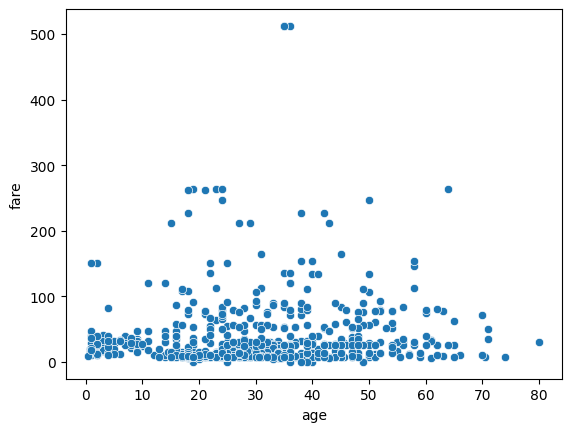

In [ ]:
# Is age related to ticket fare?
sns.scatterplot(data=df, x='age', y='fare')
plt.show()
# Not any strong relationship actually

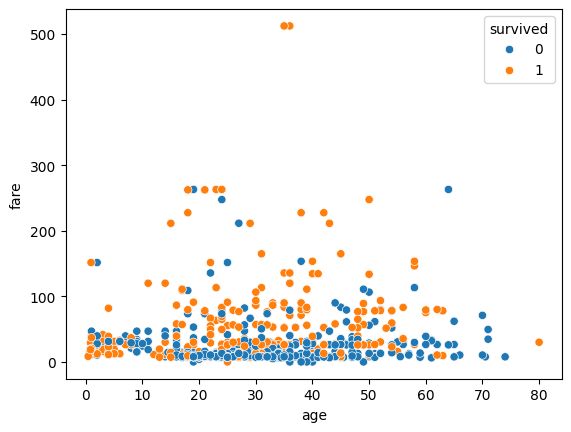

In [ ]:
# Did survivors pay higher fares?
sns.scatterplot(data=df, x='age',y='fare',hue='survived')
plt.show()
# Insight: 
# Young + High Fare     -> many survivors
# Old + Low Fare        -> many non-survivors

**Box Plot**

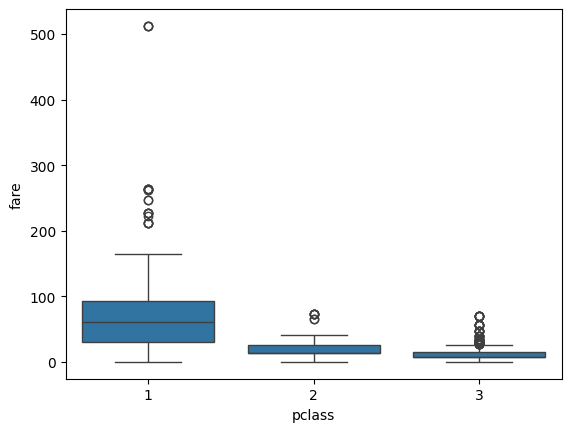

In [ ]:
# Which class paid the highest fare?
sns.boxplot(data=df, x='pclass', y='fare')
plt.show()
# Key Insights:
# Pclass 1 > Pclass 2 > Pclass 3
# First-class fares have much higher variability while third-class passengers mostly paid relatively small amounts.
# The fare distribution is right-skewed.

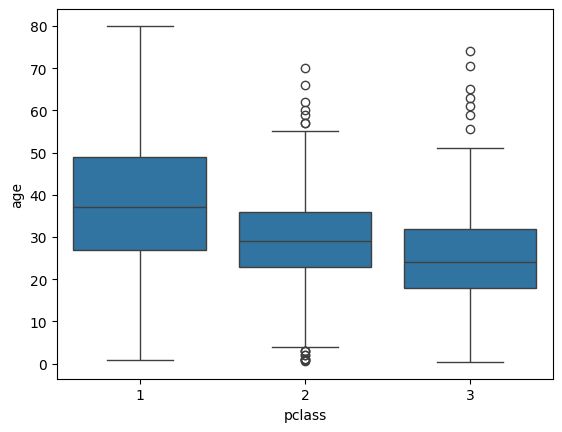

In [35]:
# Which class had older passengers ?
sns.boxplot(data=df, x='pclass', y='age')
plt.show()

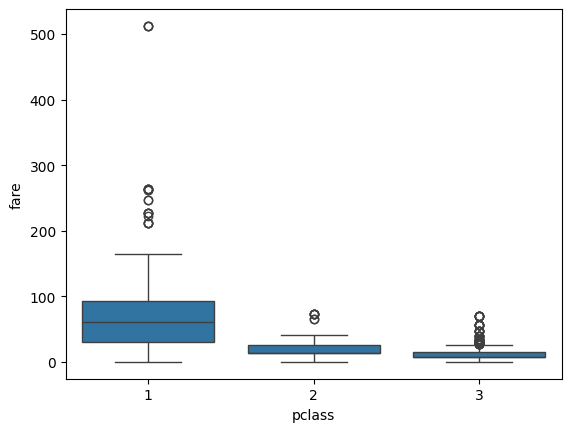

In [ ]:
# Which class contains the most fare outliers?
sns.boxplot(data=df, x='pclass', y='fare')
plt.show()
# First class contains many extreme fare outliers

**Bar Plot**

<Axes: xlabel='pclass', ylabel='fare'>

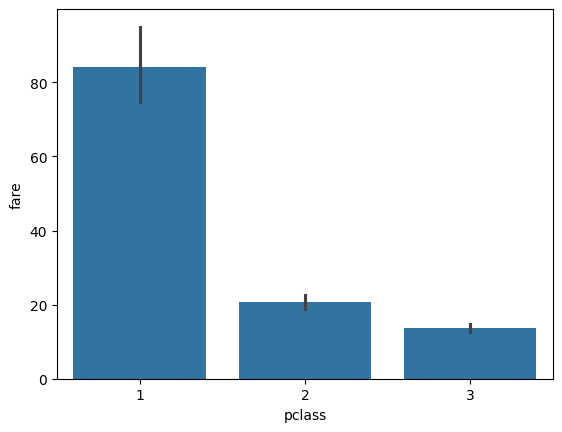

In [ ]:
# barplot = average 
# Which class had the highest average fare?
sns.barplot(data=df, x='pclass', y='fare')
# Those vertical lines are error bars

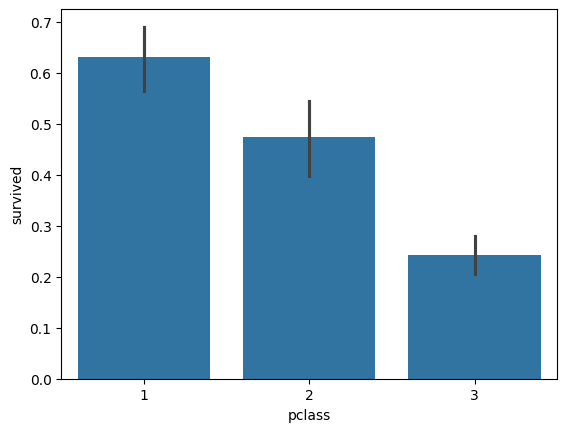

In [39]:
# Which class had the highest survival rate?
sns.barplot(data=df, x='pclass', y='survived')
plt.show()

<Axes: xlabel='sex', ylabel='survived'>

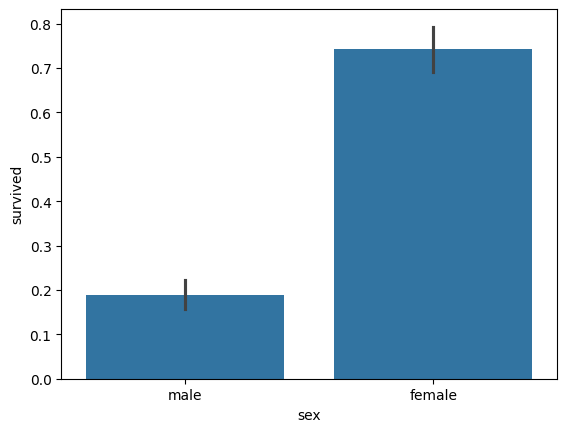

In [40]:
# Which gender had the highest survival rate?
sns.barplot(
    data=df,
    x="sex",
    y="survived"
)

<Axes: xlabel='embark_town', ylabel='survived'>

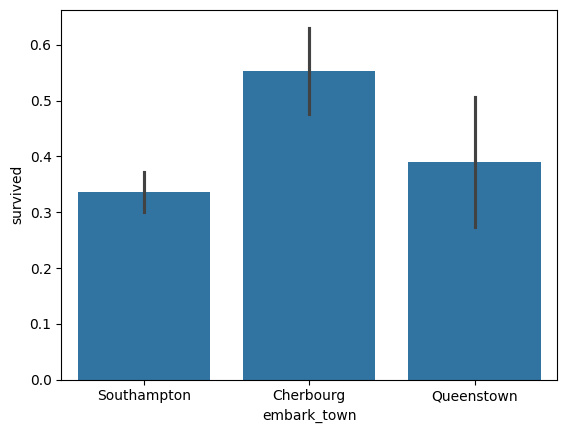

In [ ]:
# Which embarking port has higher survival rate ?
sns.barplot(
    data=df,
    x='embark_town',
    y='survived'
)

**Heatmaps**

<Axes: >

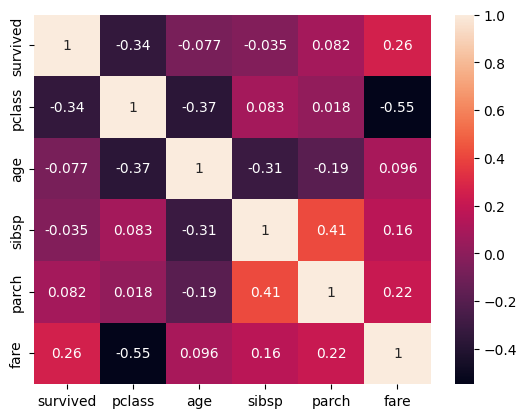

In [ ]:
# Which numerical variables are related?
corr = df.select_dtypes('number').corr()
sns.heatmap(corr, annot=True)
# Is fare correlated with survival?
# Is age correlated with fare?
# Which feature has strongest correlation with survival?

**Violin Plot**

<Axes: xlabel='pclass', ylabel='age'>

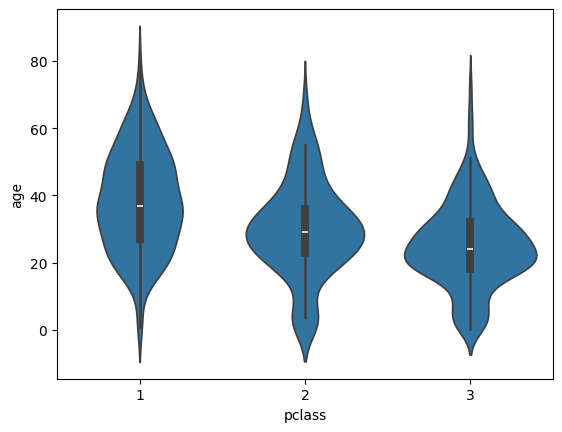

In [ ]:
# Width = density
# How is age distributed within each class?
sns.violinplot(data=df, x='pclass', y='age')\
# Third class contains more young passengers, while first class tends to have older passengers.

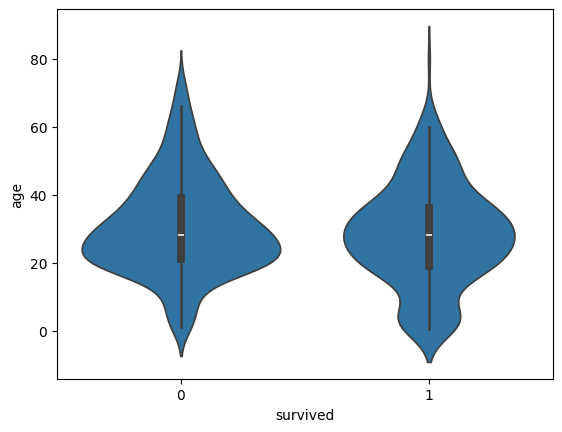

In [ ]:
# Is age distribution different between survivors and non-survivors?
sns.violinplot(data=df, x='survived', y='age')
plt.show()
# Children and younger passengers show somewhat better survival patterns.

**Pair Plot**

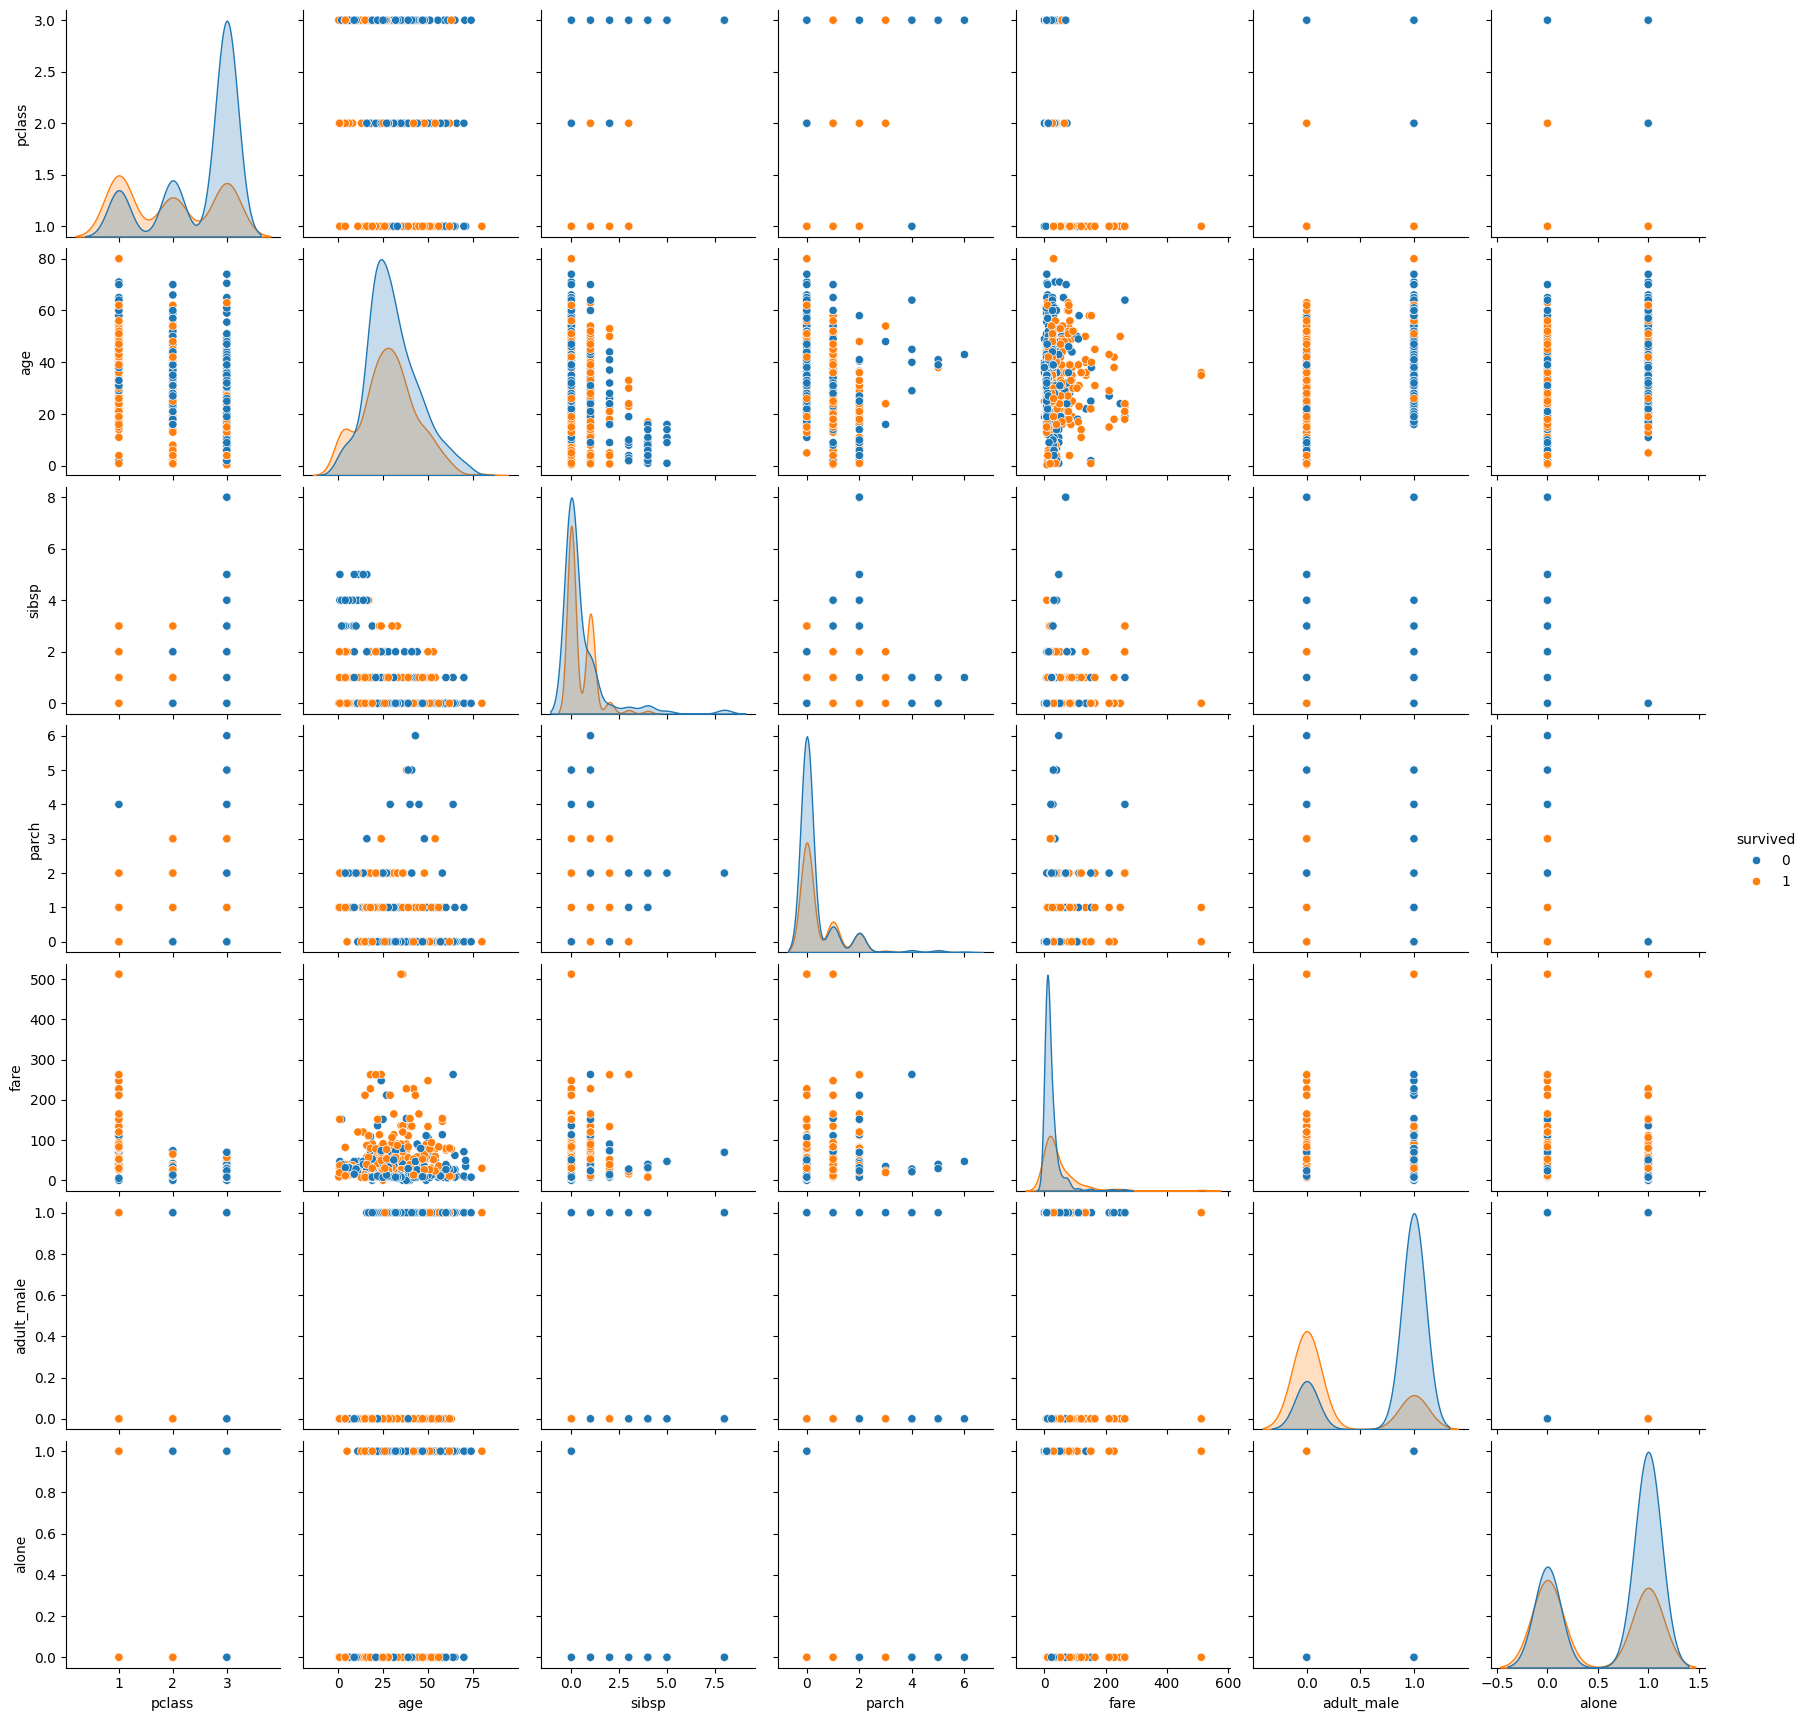

In [ ]:
# What relationships exist among all numerical features?
sns.pairplot(data=df, hue='survived')
# Do survivors cluster in certain fare ranges?
# Are there visible patterns among age, fare, and survival?